# Species Thermodynamic Properties Tutorial

This tutorial demonstrates how to work with species thermodynamic properties in KiRATE using NASA7 polynomial coefficients.

## Overview

KiRATE provides a `Species` class that encapsulates:
- NASA7 polynomial coefficients for thermodynamic properties
- CHEMKIN format parsing and export
- Automatic differentiation-compatible calculations
- Vectorized evaluation over temperature ranges

In [2]:
import time
import matplotlib.pyplot as plt
import jax.numpy as jnp

from KiRATE.species import Species, fit_smooth_nasa7_coefficients

## Creating Species Objects

### From CHEMKIN Format

The most common way to create a species is from a CHEMKIN-format thermodynamic data string. This format is the industry standard used by CHEMKIN, Cantera, and other kinetics packages.

In [4]:
# CHEMKIN format: 4 lines with NASA7 coefficients
# Line 1: Species name, composition, phase, Tmin, Tmax, Tmid
# Lines 2-4: Coefficients for high-T and low-T ranges

# Methane thermo coefficients from GRI-3.0
ch4_thermo = """
CH4               L 8/88C   1H   4          G   200.000  3500.000  1000.000    1
 7.48514950E-02 1.33909467E-02-5.73285809E-06 1.22292535E-09-1.01815230E-13    2
-9.46834459E+03 1.84373180E+01 5.14987613E+00-1.36709788E-02 4.91800599E-05    3
-4.84743026E-08 1.66693956E-11-1.02466476E+04-4.64130376E+00                   4
"""

ch4 = Species.from_chemkin(ch4_thermo)

print(f"Species: {ch4.name}")
print(f"Composition: {ch4.elemental_composition}")
print(f"Phase: {ch4.phase}")
print(f"Temperature range: {ch4.Tmin:.0f} - {ch4.Tmax:.0f} K")
print(f"Intermediate temperature: {ch4.Tmid:.0f} K")
print(f"Low temperature coefficients: {ch4.low_coeffs}")
print(f"High temperature coefficients: {ch4.high_coeffs}")

Species: CH4
Composition: {'C': 1, 'H': 4}
Phase: G
Temperature range: 200 - 3500 K
Intermediate temperature: 1000 K
Low temperature coefficients: [ 5.14987613e+00 -1.36709788e-02  4.91800599e-05 -4.84743026e-08
  1.66693956e-11 -1.02466476e+04 -4.64130376e+00]
High temperature coefficients: [ 7.48514950e-02  1.33909467e-02 -5.73285809e-06  1.22292535e-09
 -1.01815230e-13 -9.46834459e+03  1.84373180e+01]


## Computing Thermodynamic Properties

### Available Properties

The `Species` class provides methods for computing thermodynamic properties using NASA7 polynomials.

**Dimensionless properties** (divided by R or RT):
- `cp_over_r(T)` - Heat capacity Cp/R
- `h_over_rt(T)` - Enthalpy H/(RT)
- `s_over_r(T)` - Entropy S/R
- `g_over_rt(T)` - Gibbs free energy G/(RT)
- `u_over_rt(T)` - Internal energy U/(RT)
- `cv_over_r(T)` - Heat capacity at constant volume Cv/R

**Dimensional properties**:
- `cp(T)` - Heat capacity at constant pressure [cal/(mol·K)]
- `h(T)` - Enthalpy [cal/mol]
- `s(T)` - Entropy [cal/(mol·K)]
- `g(T)` - Gibbs free energy [cal/mol]
- `u(T)` - Internal energy [cal/mol]
- `cv(T)` - Heat capacity at constant volume [cal/(mol·K)]

**Species Attributes** (related to thermodynamics):
- `name` - Species identifier
- `elemental_composition` - Dict mapping elements to atom counts
- `molecular_weight` - Molecular weight [kg/mol]
- `phase` - Phase indicator: "G" (gas), "L" (liquid), "S" (solid)
- `Tmin`, `Tmax`, `Tmid` - Temperature range boundaries [K]
- `low_coeffs`, `high_coeffs` - NASA7 polynomial coefficients [a1, a2, a3, a4, a5, a6, a7]

### Scalar Evaluation

Evaluate properties at a single temperature:

In [7]:
T = 900.0  # K

print(f"Species attributes:")
print(f"  Name: {ch4.name}")
print(f"  Composition: {ch4.elemental_composition}")
print(f"  Molecular weight: {ch4.molecular_weight:.6f} kg/mol")
print(f"  Phase: {ch4.phase}")
print(f"  Temperature range: [{ch4.Tmin:.0f}, {ch4.Tmax:.0f}] K")
print(f"  Intermediate temperature: {ch4.Tmid:.0f} K\n")

print(f"Methane properties at {T:.0f} K:")
print(f"  Cp/R   = {ch4.cp_over_r(T):.4f}")
print(f"  H/(RT) = {ch4.h_over_rt(T):.4f}")
print(f"  S/R    = {ch4.s_over_r(T):.4f}")
print(f"  G/(RT) = {ch4.g_over_rt(T):.4f}")
print(f"  U/(RT) = {ch4.u_over_rt(T):.4f}")
print(f"  Cv/R   = {ch4.cv_over_r(T):.4f}\n")

print(f"Dimensional properties:")
print(f"  Cp = {ch4.cp(T):.2f} cal/(mol·K)")
print(f"  H  = {ch4.h(T):.2f} cal/mol")
print(f"  S  = {ch4.s(T):.2f} cal/(mol·K)")
print(f"  G  = {ch4.g(T):.2f} cal/mol")
print(f"  U  = {ch4.u(T):.2f} cal/mol")
print(f"  Cv = {ch4.cv(T):.2f} cal/(mol·K)")

Species attributes:
  Name: CH4
  Composition: {'C': 1, 'H': 4}
  Molecular weight: 16.043000 kg/mol
  Phase: G
  Temperature range: [200, 3500] K
  Intermediate temperature: 1000 K

Methane properties at 900 K:
  Cp/R   = 8.2809
  H/(RT) = -5.7557
  S/R    = 28.9592
  G/(RT) = -34.7149
  U/(RT) = -6.7557
  Cv/R   = 7.2809

Dimensional properties:
  Cp = 16.46 cal/(mol·K)
  H  = -10293.97 cal/mol
  S  = 57.55 cal/(mol·K)
  G  = -62086.98 cal/mol
  U  = -12082.45 cal/mol
  Cv = 14.47 cal/(mol·K)


### Vectorized Evaluation

Efficiently evaluate properties over a temperature range:

In [8]:
# Create temperature array
T_range = jnp.linspace(300, 3000, 300)

# Compute properties (vectorized - runs efficiently in JAX)
cp_values = ch4.cp(T_range)
h_values  = ch4.h(T_range)
s_values  = ch4.s(T_range)
g_values  = ch4.g(T_range)

print(f"Computed {len(T_range)} temperature points")
print(f"Temperature range: {T_range[0]:.0f} - {T_range[-1]:.0f} K")

Computed 300 temperature points
Temperature range: 300 - 3000 K


## Performance Optimization

### Efficient Multi-Property Evaluation

When evaluating **multiple properties** at the **same temperatures**, use the `evaluate()` method to avoid redundant computations. This method computes temperature powers once and reuses them for all requested properties.

**Performance comparison:**
- **Individual calls:** Each property method computes temperature powers independently (baseline)
- **`evaluate()` method:** Temperature powers computed once and shared (~1.3x faster)
- **`evaluate_all()` method:** Computes all 6 properties efficiently
- **`evaluate()` with JIT:** Add JAX JIT compilation for maximum performance (~100-150x faster!)

Let's compare the approaches:

Method 1: Individual property calls
  Time: 0.5466 seconds

Method 2: Using evaluate() method
  Time: 0.4120 seconds
  Speedup: 1.33x faster!

Method 3: Using evaluate_all() for all properties
  Time: 0.5631 seconds
  Returns: ['cp', 'h', 's', 'g', 'u', 'cv']
  Speedup vs individual (4 props): 0.97x
  Note: Computes 6 properties vs 4 in Method 1



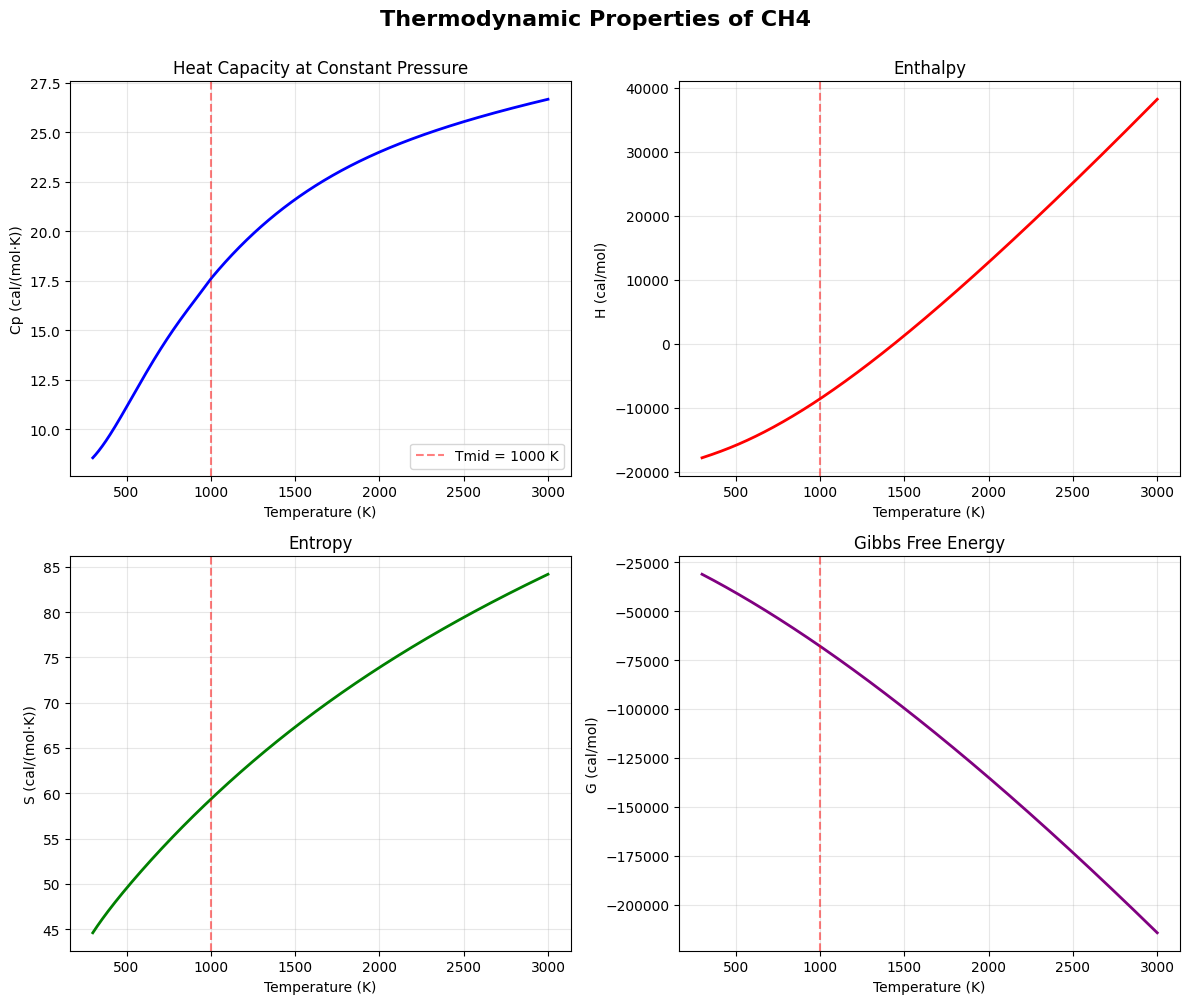

In [10]:
T_range = jnp.linspace(300, 3000, 1000)

# Method 1: Individual property calls (less efficient)
print("Method 1: Individual property calls")
start = time.time()
for _ in range(100):
    cp = ch4.cp(T_range)
    h = ch4.h(T_range)
    s = ch4.s(T_range)
    g = ch4.g(T_range)
time_individual = time.time() - start
print(f"  Time: {time_individual:.4f} seconds\n")

# Method 2: Using evaluate() method (more efficient)
print("Method 2: Using evaluate() method")
start = time.time()
for _ in range(100):
    props = ch4.evaluate(T_range, properties=['cp', 'h', 's', 'g'])
    cp = props['cp']
    h = props['h']
    s = props['s']
    g = props['g']
time_evaluate = time.time() - start
print(f"  Time: {time_evaluate:.4f} seconds")
print(f"  Speedup: {time_individual / time_evaluate:.2f}x faster!\n")

# Method 3: Using evaluate_all() for all properties
print("Method 3: Using evaluate_all() for all properties")
start = time.time()
for _ in range(100):
    all_props = ch4.evaluate_all(T_range)
time_evaluate_all = time.time() - start
print(f"  Time: {time_evaluate_all:.4f} seconds")
print(f"  Returns: {list(all_props.keys())}")
print(f"  Speedup vs individual (4 props): {time_individual / time_evaluate_all:.2f}x")
print(f"  Note: Computes 6 properties vs 4 in Method 1\n")

# Now let's visualize the properties
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Use evaluate() for efficient computation
props = ch4.evaluate(T_range, properties=['cp', 'h', 's', 'g'])

# Plot Cp
axes[0, 0].plot(T_range, props['cp'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Temperature (K)')
axes[0, 0].set_ylabel('Cp (cal/(mol·K))')
axes[0, 0].set_title('Heat Capacity at Constant Pressure')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(ch4.Tmid, color='r', linestyle='--', alpha=0.5, label=f'Tmid = {ch4.Tmid:.0f} K')
axes[0, 0].legend()

# Plot H
axes[0, 1].plot(T_range, props['h'], 'r-', linewidth=2)
axes[0, 1].set_xlabel('Temperature (K)')
axes[0, 1].set_ylabel('H (cal/mol)')
axes[0, 1].set_title('Enthalpy')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(ch4.Tmid, color='r', linestyle='--', alpha=0.5)

# Plot S
axes[1, 0].plot(T_range, props['s'], 'g-', linewidth=2)
axes[1, 0].set_xlabel('Temperature (K)')
axes[1, 0].set_ylabel('S (cal/(mol·K))')
axes[1, 0].set_title('Entropy')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(ch4.Tmid, color='r', linestyle='--', alpha=0.5)

# Plot G
axes[1, 1].plot(T_range, props['g'], 'purple', linewidth=2)
axes[1, 1].set_xlabel('Temperature (K)')
axes[1, 1].set_ylabel('G (cal/mol)')
axes[1, 1].set_title('Gibbs Free Energy')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(ch4.Tmid, color='r', linestyle='--', alpha=0.5)

plt.suptitle('Thermodynamic Properties of CH4', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## NASA7 Polynomial Discontinuities

Standard NASA7 polynomials can have discontinuities at the intermediate temperature (Tmid) where the low-T and high-T polynomials meet. Let's visualize this:

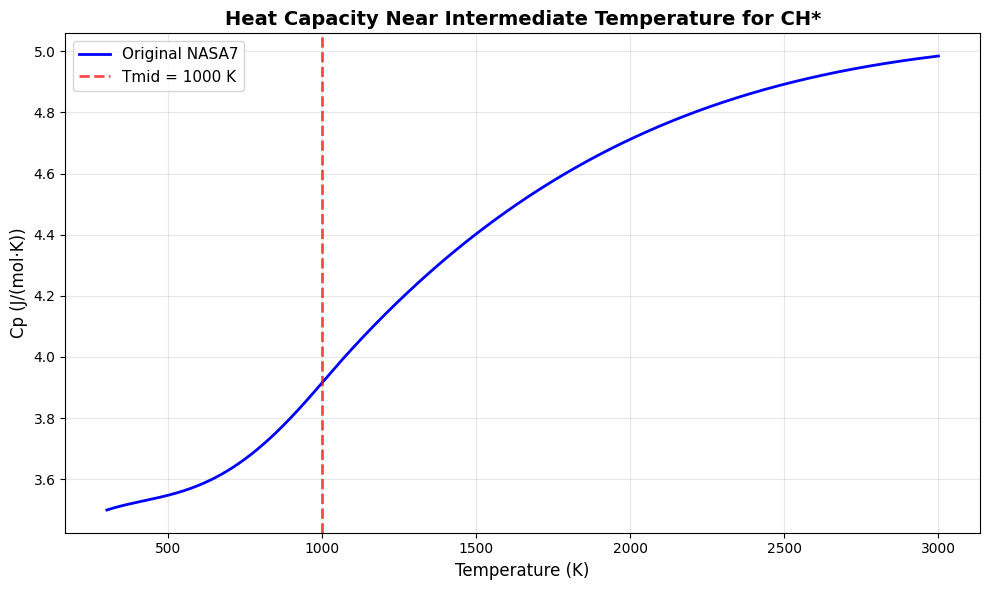

In [15]:
# Use a species with a visible discontinuity
ch_radical = """
    CH*               073003C   1H   1          G  0300.00   5000.00  1000.00      1
     0.02196223E+02 0.02340381E-01-0.07058201E-05 0.09007582E-09-0.03855040E-13    2
     0.10419559E+06 0.09178373E+02 0.03200202E+02 0.02072875E-01-0.05134431E-04    3
     0.05733890E-07-0.01955533E-10 0.10393714E+06 0.03331587E+02                   4
"""
ch = Species.from_chemkin(ch_radical)

cp_over_r = ch.cp_over_r(T_range)

# Evaluate near the intermediate temperature
plt.figure(figsize=(10, 6))
plt.plot(T_range, cp_over_r, 'b-', linewidth=2, label='Original NASA7')
plt.axvline(ch.Tmid, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Tmid = {ch.Tmid:.0f} K')
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel('Cp (J/(mol·K))', fontsize=12)
plt.title(f'Heat Capacity Near Intermediate Temperature for {ch.name}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Smooth NASA7 Polynomial Fitting

KiRATE provides `fit_smooth_nasa7_coefficients()` to eliminate discontinuities by refitting the NASA7 coefficients using a spline basis. This ensures:

- Continuous Cp, H, S, and G across Tmid
- Continuous derivatives (smooth transitions)
- Preservation of original thermodynamic values at Tmid

### Fixed Intermediate Temperature

Refit with a specified Tmid:

Original species: Tmid = 1000 K
Smooth fitted species: Tmid = 1000 K


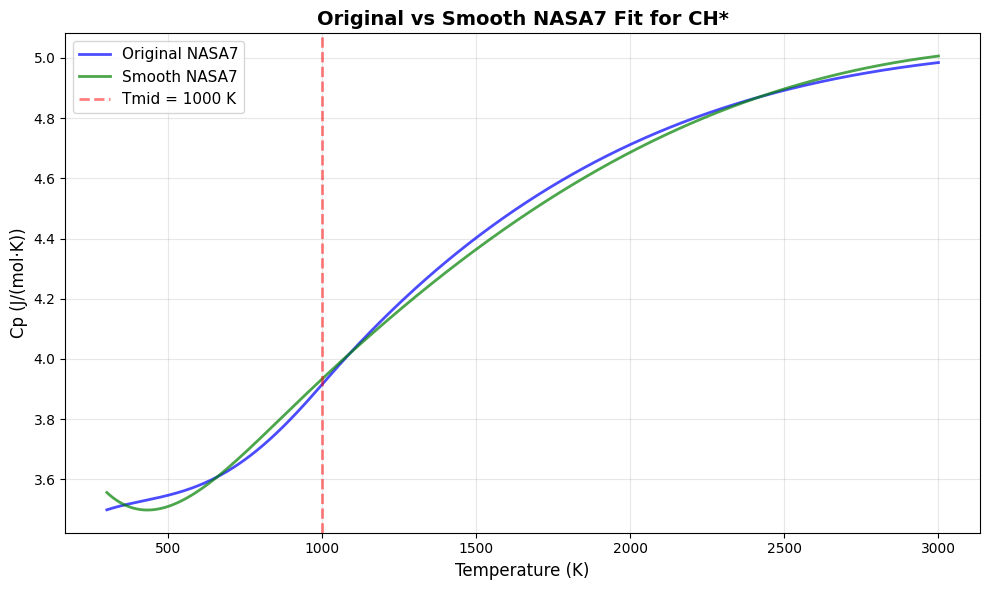

In [17]:
# Fit with the original Tmid
ch_smooth = fit_smooth_nasa7_coefficients(ch, T_mid=1000.0)

print(f"Original species: Tmid = {ch.Tmid:.0f} K")
print(f"Smooth fitted species: Tmid = {ch_smooth.Tmid:.0f} K")

# Compare original and smooth fit
cp_smooth = ch_smooth.cp_over_r(T_range)

plt.figure(figsize=(10, 6))
plt.plot(T_range, cp_over_r, 'b-', linewidth=2, label='Original NASA7', alpha=0.7)
plt.plot(T_range, cp_smooth, 'g-', linewidth=2, label='Smooth NASA7', alpha=0.7)
plt.axvline(ch.Tmid, color='r', linestyle='--', linewidth=2, alpha=0.5, label=f'Tmid = {ch.Tmid:.0f} K')
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel('Cp (J/(mol·K))', fontsize=12)
plt.title(f'Original vs Smooth NASA7 Fit for {ch.name}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Automatic Tmid Optimization

Let the algorithm search for the optimal intermediate temperature that minimizes fitting error:

Original species: Tmid = 1000 K
Auto-optimized species: Tmid = 1616 K
Optimal Tmid found: 1616 K


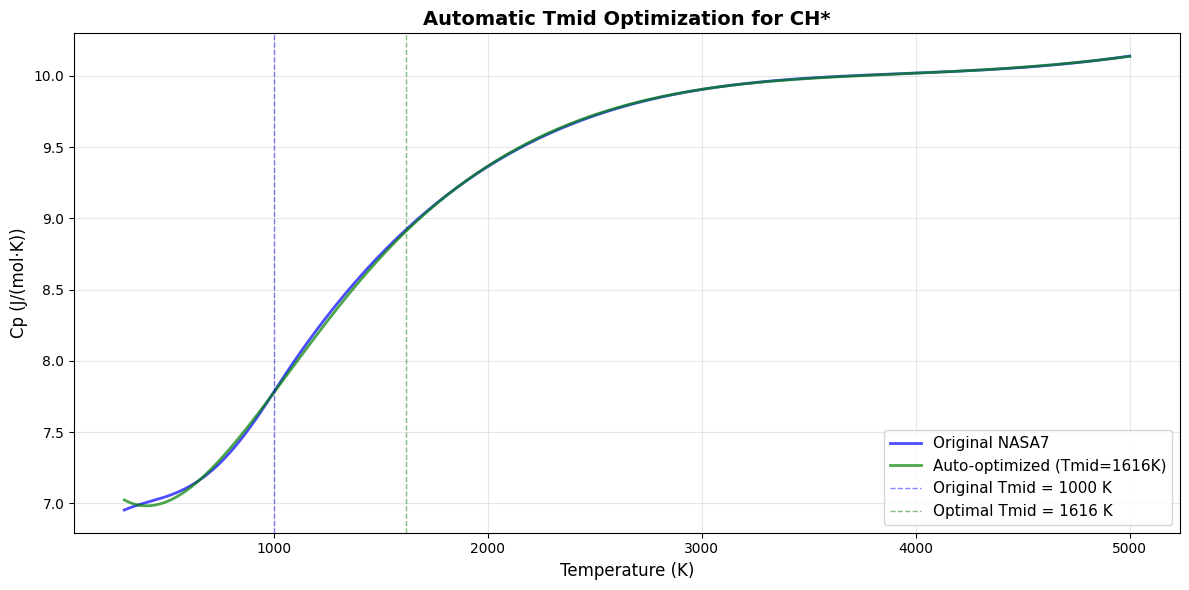

In [18]:
# Automatic search for optimal Tmid
ch_auto = fit_smooth_nasa7_coefficients(ch)

print(f"Original species: Tmid = {ch.Tmid:.0f} K")
print(f"Auto-optimized species: Tmid = {ch_auto.Tmid:.0f} K")
print(f"Optimal Tmid found: {ch_auto.Tmid:.0f} K")

# Evaluate over full temperature range
T_full = jnp.linspace(ch.Tmin, ch.Tmax, 300)
cp_original = ch.cp(T_full)
cp_auto = ch_auto.cp(T_full)

plt.figure(figsize=(12, 6))
plt.plot(T_full, cp_original, 'b-', linewidth=2, label='Original NASA7', alpha=0.7)
plt.plot(T_full, cp_auto, 'g-', linewidth=2, label=f'Auto-optimized (Tmid={ch_auto.Tmid:.0f}K)', alpha=0.7)
plt.axvline(ch.Tmid, color='blue', linestyle='--', linewidth=1, alpha=0.5, label=f'Original Tmid = {ch.Tmid:.0f} K')
plt.axvline(ch_auto.Tmid, color='green', linestyle='--', linewidth=1, alpha=0.5, label=f'Optimal Tmid = {ch_auto.Tmid:.0f} K')
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel('Cp (J/(mol·K))', fontsize=12)
plt.title(f'Automatic Tmid Optimization for {ch.name}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Automatic Differentiation

All thermodynamic property calculations are compatible with JAX's automatic differentiation. This is crucial for optimization and sensitivity analysis.

### Computing Gradients with JAX

Let's compute dCp/dT using automatic differentiation and compare it with the analytical derivative:

At T = 1000 K:
  Cp            = 17.5948 cal/(mol·K)
  dCp/dT (auto) = 0.010307 cal/(mol·K²)
  dCp/dT (analytical) = 0.010307 cal/(mol·K²)
  Difference    = 3.47e-18 cal/(mol·K²)

✓ Autodiff and analytical gradients match!


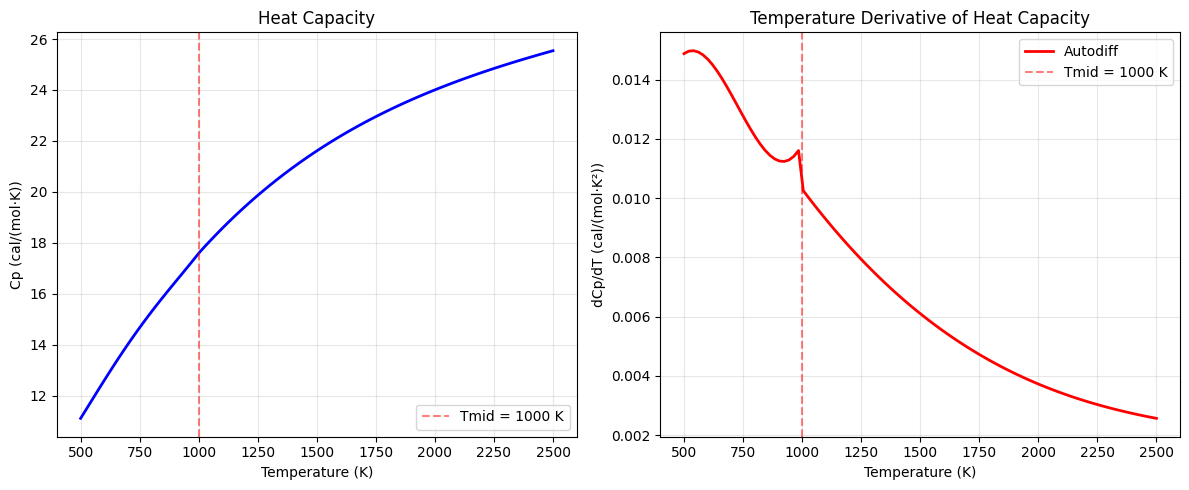

In [19]:
import jax

# Compute derivative of Cp with respect to temperature using JAX autodiff
def cp_func(T):
    return ch4.cp(T)

dcp_dT_autodiff = jax.grad(cp_func)

# Analytical derivative of Cp from NASA7 polynomial
# Cp/R = a1 + a2*T + a3*T^2 + a4*T^3 + a5*T^4
# dCp/dT = R * (a2 + 2*a3*T + 3*a4*T^2 + 4*a5*T^3)
def dcp_dT_analytical(T, coeffs, R_cal_mol_K):
    """Analytical derivative of Cp with respect to T."""
    a1, a2, a3, a4, a5, a6, a7 = coeffs
    return R_cal_mol_K * (a2 + 2*a3*T + 3*a4*T**2 + 4*a5*T**3)

T_test = 1000.0
cp_val = ch4.cp(T_test)
dcp_autodiff = dcp_dT_autodiff(T_test)

# Get the appropriate coefficients based on temperature
coeffs = ch4.low_coeffs if T_test < ch4.Tmid else ch4.high_coeffs
from KiRATE.utilities.physical_constants import constants
dcp_analytical = dcp_dT_analytical(T_test, coeffs, constants.R_cal_mol_K)

print(f"At T = {T_test:.0f} K:")
print(f"  Cp            = {cp_val:.4f} cal/(mol·K)")
print(f"  dCp/dT (auto) = {dcp_autodiff:.6f} cal/(mol·K²)")
print(f"  dCp/dT (analytical) = {dcp_analytical:.6f} cal/(mol·K²)")
print(f"  Difference    = {abs(dcp_autodiff - dcp_analytical):.2e} cal/(mol·K²)")
print()
print("✓ Autodiff and analytical gradients match!")

# Vectorized gradient computation
T_range_grad = jnp.linspace(500, 2500, 100)
dcp_autodiff_vec = jax.vmap(dcp_dT_autodiff)(T_range_grad)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Cp
ax1.plot(T_range_grad, ch4.cp(T_range_grad), 'b-', linewidth=2)
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('Cp (cal/(mol·K))')
ax1.set_title('Heat Capacity')
ax1.grid(True, alpha=0.3)
ax1.axvline(ch4.Tmid, color='r', linestyle='--', alpha=0.5, label=f'Tmid = {ch4.Tmid:.0f} K')
ax1.legend()

# Plot dCp/dT
ax2.plot(T_range_grad, dcp_autodiff_vec, 'r-', linewidth=2, label='Autodiff')
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('dCp/dT (cal/(mol·K²))')
ax2.set_title('Temperature Derivative of Heat Capacity')
ax2.grid(True, alpha=0.3)
ax2.axvline(ch4.Tmid, color='r', linestyle='--', alpha=0.5, label=f'Tmid = {ch4.Tmid:.0f} K')
ax2.legend()

plt.tight_layout()
plt.show()

## Exporting to CHEMKIN Format

Species can be exported back to CHEMKIN format for use in other tools:

In [20]:
# Export smooth-fitted species to CHEMKIN format
# The Species class implements __str__() which returns CHEMKIN format
chemkin_output = str(ch_smooth)

print("Smooth-fitted species in CHEMKIN format:")
print(chemkin_output)

Smooth-fitted species in CHEMKIN format:
CH*                     C   1H   1          G    300.00   5000.00   1000.00    1
 2.83667552E+00 1.18552081E-03-2.57341171E-08-7.11171361E-11 9.44406201E-15    2
 1.03943511E+05 5.61950714E+00 4.37041246E+00-4.94942695E-03 9.17668753E-06    3
-6.20606490E-09 1.54318100E-12 1.03636763E+05-1.77988702E+00                   4
